In [2]:
#Importing some important libraries for the model like (Numpy, Pandas, Matplotlib).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Printing the version of these libraries.
print(np.__version__)
print(pd.__version__)

2.5.0
3.0.3


In [3]:
#Using pandas to import the data from the Excel file ("AgeOfStudent") to a numpy array giving the name X.
X=pd.read_excel("AgeNAvgStudyHour.xlsx").to_numpy()
#Using pandas to import the data from the Excel file ("Marks") and converting it to a one-dimension (1D) numpy array giving the name y.
y=pd.read_excel("Marks.xlsx").to_numpy().flatten()

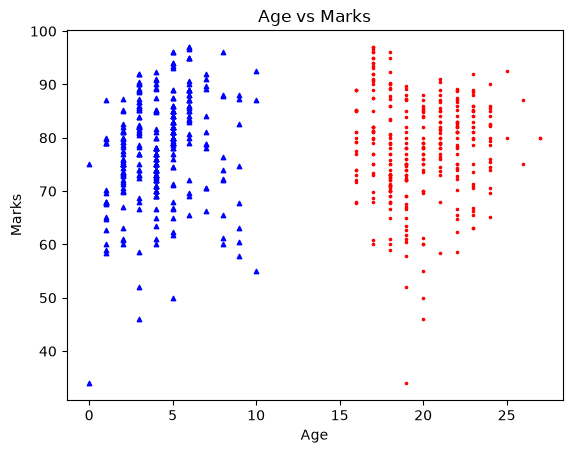

In [4]:
#Using the .title() function of matplotlib giving the graph a title of ("Linear Regression: Student Age vs Marks in (%)").
plt.title('Age vs Marks')
#Using the .xlabel() function of matplotlib giving the graph x-axis the name of ('Age and Avg Hour Of Study').
plt.xlabel('Age and Avg Hour Of Study')
#Using the .ylabel() function of matplotlib giving the graph y-axis the name of ('Marks in (%)')
plt.ylabel('Marks in (%)')

# Use X[:, 0] to plot the entire Age column
plt.scatter(X[:, 0], y, color='red', s=10, marker='.', label='Age')
#Using matplotlib plotting a scatter plot of X and y, with the size of 10, color red
# Use X[:, 1] to plot the entire AvgStudyHour column
plt.scatter(X[:, 1], y, color='blue', s=10, marker='^', label='Study Hours')
#Using the function named .show() showing the plotted graph
plt.show()

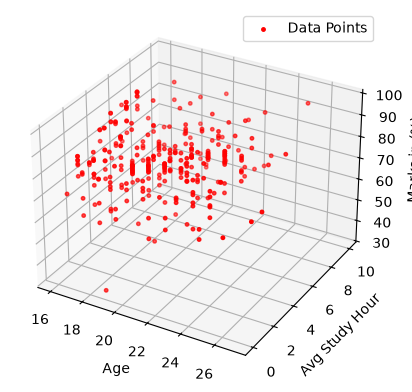

In [13]:

can = plt.figure()

ax = can.add_subplot(projection='3d')

#Using matplotlib plotting a 3d scatter plot of X and y, with the size of 25, color red.
ax.scatter(X[:, 0], X[:, 1], y, s=25, c='red', marker='.', label='Data Points')
#Using the .set_xlabel() function of matplotlib giving the graph x-axis the name of ('Age').
ax.set_xlabel('Age')
#Using the .set_ylabel() function of matplotlib giving the graph x-axis the name of ('Avg Study Hour').
ax.set_ylabel('Avg Study Hour')
#Using the .set_zlabel() function of matplotlib giving the graph x-axis the name of ('Marks in (%)')
ax.set_zlabel('Marks in (%)')
# Display the legend to easily distinguish between the data points and the regression plane
ax.legend()
#Using the function named .show() showing the plotted graph
plt.show()

In [5]:
#Delaring weight as w to help the model to generalize better to unseen test data set also it help in preventing overfitting.
w=np.zeros(X.shape[1])
#The bias acts as the model's baseline anchor. It represents the predicted base score when all input features are zero, shifting the regression line vertically to properly fit the dataset.
b=0.1
#Delaring learning rate as learning_rate to control the step size during optimization a higher learning rate will speed up training but risk overshooting optimal value and a lower learning rate leads to slow convergence and requires more epochs, because of this we choose an optimal balance learning rate of 0.001.
learning_rate=0.001

In [6]:
#The Cost Function (Mean Squared Error) is simply the model's scoreboard. Its only job is to look at the current line and calculate exactly how many "points" it missed the real data by.
def compute_cost(X,y,w,b):
    #m is the total number of data points in are data set.
    m=len(y)
    cost=0
    for i in range(m):
        # Using our current w and b, predict the Marks for every Age.
        fx=w[i]*X[i]+b
        #Subtract the actual Marks from our predictions and add them after squaring them to see how far off we were.
        cost+=(fx-y[i])**2
    #Add up all the squared errors and divide by 'm' to get the Mean (Average) Squared Error.
    total_cost=(1/(2*m))*cost
    return total_cost

In [7]:
#The Gradients tell us which direction to step to get better. This calculates the slope of the error hill.
def compute_grad(X,y,w,b):
    #m is the total number of data points in are data set.
    m=len(y)
    dj_dw=np.zeros(X.shape[1])
    dj_db=0

     #Calculate our current predictions based on the current line.
    fx=np.dot(X,w)+b
    errors = fx - y

    #We multiply the errors by X (Age). If a large Age caused a large error, it means our weight (slope) is way off and needs a bigger adjustment.
    dj_dw = np.dot(X.T, errors) / m
     #We just take the average of all the raw errors.
    dj_db = np.sum(errors) / m

    return dj_dw,dj_db

In [8]:
epochs = 2000
for epoch in range(epochs):
    #Which way should I adjust w and b to lower the error
    dj_dw, dj_db = compute_grad(X,y,w,b)

    #Update our parameters. We SUBTRACT the gradient because we want to go DOWN the error hill, not up. We multiply by learning_rate to ensure the step is small enough that we don't explode past the bottom.
    w= w - (learning_rate * dj_dw)
    b = b - (learning_rate * dj_db)

In [9]:
m = len(y)
predicted = np.zeros(m)

predicted = np.dot(X, w) + b

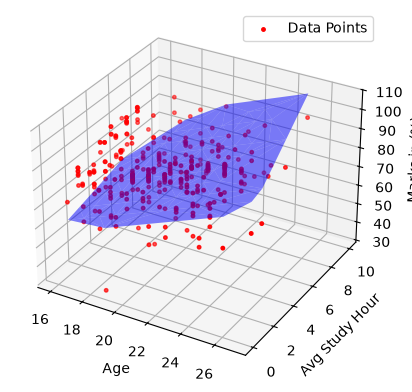

In [10]:
can = plt.figure()
ax = can.add_subplot(projection='3d')

#Using matplotlib plotting a 3d surface plot of X and predicted,with color blue.
ax.plot_trisurf(X[:, 0], X[:, 1], predicted, color='blue', alpha=0.5)
#Using matplotlib plotting a scatter plot of X and y, with the size of 25, color red.
ax.scatter(X[:, 0], X[:, 1], y, s=25, c='red', marker='.', label='Data Points')
#Using the .set_xlabel() function of matplotlib giving the graph x-axis the name of ('Age').
ax.set_xlabel('Age')
#Using the .set_ylabel() function of matplotlib giving the graph x-axis the name of ('Avg Study Hour').
ax.set_ylabel('Avg Study Hour')
#Using the .set_zlabel() function of matplotlib giving the graph x-axis the name of ('Marks in (%)').
ax.set_zlabel('Marks in (%)')
# Display the legend to easily distinguish between the data points and the regression plane
ax.legend()
#Using the function named .show() showing the plotted graph
plt.show()

In [14]:
Age=0
#Validate Age of the user
Age=int(input("Enter Age: "))
while Age<=0 or Age >= 100:
    print("Invalid Age! Please enter a value between 1 and 99.\n")
    Age=int(input("Enter Age: "))

AvgStudyHour=-1
#Validate Average Study Hours of the user
AvgStudyHour=int(input("Enter Avg Study Hour: "))
while AvgStudyHour <0 or AvgStudyHour >= 12:
    print("Invalid Hours! Please enter a value between 0 and 11.\n")
    AvgStudyHour=int(input("Enter Avg Study Hour: "))

#Calculate Prediction
# Using the linear regression equation: Y = w1*X1 + w2*X2 + b
marks=round((w[0]*Age)+(w[1]*AvgStudyHour)+b,2)

print("Predicted Marks:",marks,"%")

70.60825590704626
